# Computer Exercise 14.5 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 14.5 Monitoring & Drift Detection — *Detecting data (covariate) drift*
> **풀이 일자**: 2026-07-05 · **언어**: 한국어 (그래프 라벨은 영문)

Day60(§14.4)에서 파이프라인을 새 도메인으로 **전이**했다. 그러나 운영 중에는 target 분포가
*시간에 따라* 계속 변한다. 이번 문제는 그 첫 신호인 **데이터 드리프트(공변량 이동)** —
입력 $x$의 분포 $p_t(x)$ 자체가 참조창(reference)에서 멀어지는 현상 — 을
**KS 통계량**과 **PSI(Population Stability Index)** 로 정량 감지한다.

## 1. 문제 (원문)

> **1.** A model is deployed and receives input batches over time. Simulate a data stream in which the
> covariate distribution $p_t(x)$ is stationary for an initial period and then gradually drifts
> (a mean shift plus a variance change). Using a fixed *reference window*, monitor each incoming batch
> with (a) the two-sample **Kolmogorov-Smirnov** statistic and (b) the **Population Stability Index**.
> Plot both statistics over time, mark the alarm thresholds, and report the detection time. Discuss the
> trade-off between sensitivity and false alarms.

### 한국어 풀이용 정리
- 초기에는 정상(stationary), 어느 시점부터 $x$의 평균·분산이 서서히 이동하는 스트림을 만든다.
- 고정된 **참조창** 대비 각 배치의 **KS 통계량**과 **PSI** 를 계산해 시간축에 그린다.
- 경보 임계값을 넘는 **최초 감지 시점**을 보고하고, 민감도 ↔ 오경보의 균형을 논한다.

## 2. 수학적 배경

### 2.1 공변량 이동
$y\mid x$ 관계(개념)는 그대로지만 입력 주변분포가 바뀌는 경우:
$$p_{\text{ref}}(x)\;\ne\;p_t(x),\qquad p(y\mid x)\ \text{불변}.$$
모형은 그대로여도 학습 시 못 본 영역으로 입력이 이동하면 **외삽 오차**가 커진다.

### 2.2 두-표본 Kolmogorov-Smirnov 통계량
경험분포함수 $F_{\text{ref}},\,F_t$ 에 대해
$$D_t=\sup_x\bigl|F_{\text{ref}}(x)-F_t(x)\bigr|.$$
$D_t\in[0,1]$; 두 표본이 같은 분포면 $D_t\to 0$. 임계값은 근사식
$\;D^\*=c(\alpha)\sqrt{(n_{\text{ref}}+n_t)/(n_{\text{ref}}n_t)}$, $c(0.05)\approx1.36$ 로 잡는다.

### 2.3 Population Stability Index (PSI)
공통 구간경계로 두 분포를 $B$개의 빈으로 나눠 비율 $r_i^{\text{ref}},\,r_i^{t}$ 를 얻으면
$$\mathrm{PSI}=\sum_{i=1}^{B}\bigl(r_i^{t}-r_i^{\text{ref}}\bigr)\ln\frac{r_i^{t}}{r_i^{\text{ref}}}.$$
이는 대칭화된 KL 발산이며 산업 관례상
$\boxed{\ \mathrm{PSI}<0.1\ \text{안정},\ \ 0.1\!-\!0.25\ \text{경계},\ \ >0.25\ \text{유의한 이동}\ }$.

## 3. 풀이 흐름

1. **참조창 생성**: 정상 구간의 $x\sim\mathcal N(0,1)$ 로 참조 표본 확보.
2. **스트림 생성**: 배치 $t=0,\dots,T$. $t<t_0$ 는 정상, 이후 평균 $\mu_t$·표준편차 $\sigma_t$ 를 선형 증가.
3. **KS 통계량**: 각 배치 vs 참조창의 $D_t$ 를 경험분포로 직접 계산.
4. **PSI**: 참조창 분위수로 빈 경계를 고정하고 각 배치의 PSI 계산.
5. **임계값 + 지속성**: KS는 근사 임계값, PSI는 0.25 관례선. 연속 $k{=}2$배치 초과 시에만 경보(오경보 완충).
6. **감지 시점**: 지속성 규칙으로 처음 경보가 뜨는 배치 index 기록.
7. **시각화**: (좌) 초기 vs 후기 분포, (우) KS·PSI의 시간 궤적 + 임계선 + 감지 마커.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(1405)
n_ref = 2000
x_ref = rng.normal(0.0, 1.0, n_ref)

T, n_b, t0 = 60, 500, 25
def batch_params(t):
    if t < t0: return 0.0, 1.0
    s = (t - t0) / (T - t0)
    return 1.6*s, 1.0 + 0.9*s

def ks_stat(a, b):
    allv = np.concatenate([a, b]); allv.sort()
    Fa = np.searchsorted(np.sort(a), allv, side='right') / len(a)
    Fb = np.searchsorted(np.sort(b), allv, side='right') / len(b)
    return np.max(np.abs(Fa - Fb))

B = 10
edges = np.quantile(x_ref, np.linspace(0,1,B+1)); edges[0], edges[-1] = -np.inf, np.inf
r_ref = np.histogram(x_ref, bins=edges)[0]/n_ref; eps=1e-6
def psi(xb):
    rt=np.histogram(xb,bins=edges)[0]/len(xb)
    rt=np.clip(rt,eps,None); rr=np.clip(r_ref,eps,None)
    return np.sum((rt-rr)*np.log(rt/rr))

rows, batches = [], {}
for t in range(T):
    mu, sig = batch_params(t)
    xb = rng.normal(mu, sig, n_b); batches[t]=xb
    rows.append({'t':t,'mu':mu,'sigma':sig,'KS':ks_stat(x_ref,xb),'PSI':psi(xb)})
df = pd.DataFrame(rows)

c_alpha = 1.36
ks_thr  = c_alpha*np.sqrt((n_ref+n_b)/(n_ref*n_b))
psi_thr = 0.25
def first_persistent(series, thr, k=2):
    run=0
    for t,v in enumerate(series):
        run = run+1 if v>thr else 0
        if run>=k: return t-k+1
    return None
raw_ks  = int(df.loc[df['KS'] >ks_thr, 't'].min()) if (df['KS'] >ks_thr ).any() else None
raw_psi = int(df.loc[df['PSI']>psi_thr,'t'].min()) if (df['PSI']>psi_thr).any() else None
det_ks  = first_persistent(df['KS'].values,  ks_thr,  2)
det_psi = first_persistent(df['PSI'].values, psi_thr, 2)
print(f"KS  임계값 = {ks_thr:.4f}")
print(f"  단발 교차 t = {raw_ks}  (정상 구간 표본 스파이크 = 오경보 가능)")
print(f"  지속성(k=2) 경보 t = {det_ks}")
print(f"PSI 임계값 = {psi_thr:.2f}")
print(f"  단발 교차 t = {raw_psi} ,  지속성(k=2) 경보 t = {det_psi}")
print(f"실제 드리프트 시작 배치 t0 = {t0}")

KS  임계값 = 0.0680
  단발 교차 t = 13  (정상 구간 표본 스파이크 = 오경보 가능)
  지속성(k=2) 경보 t = 29
PSI 임계값 = 0.25
  단발 교차 t = 37 ,  지속성(k=2) 경보 t = 37
실제 드리프트 시작 배치 t0 = 25


In [2]:
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
show = df[df['t'].isin([0,10,20,t0,t0+3,t0+6,t0+10,T-1])].copy()
print("=== 대표 배치의 드리프트 지표 ===")
print(show.to_string(index=False))

=== 대표 배치의 드리프트 지표 ===
 t        mu     sigma        KS       PSI
 0 0.000e+00 1.000e+00 3.650e-02 1.911e-02
10 0.000e+00 1.000e+00 3.500e-02 1.401e-02
20 0.000e+00 1.000e+00 2.950e-02 1.804e-02
25 0.000e+00 1.000e+00 5.300e-02 2.227e-02
28 1.371e-01 1.077e+00 3.100e-02 1.634e-02
31 2.743e-01 1.154e+00 9.900e-02 7.757e-02
35 4.571e-01 1.257e+00 1.615e-01 1.837e-01
59 1.554e+00 1.874e+00 4.730e-01 1.277e+00


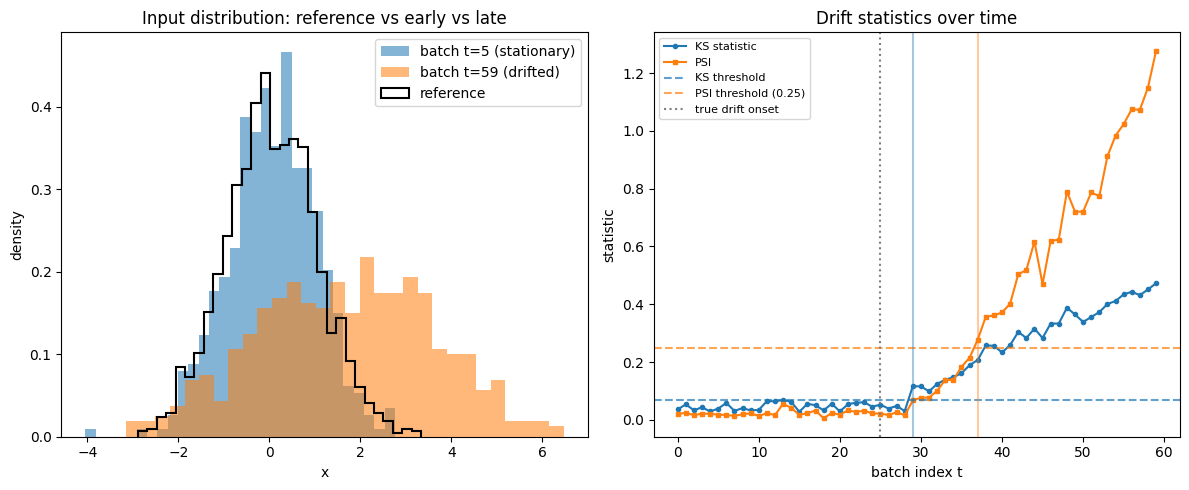

In [3]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
ax=axes[0]
ax.hist(batches[5],bins=30,density=True,alpha=0.55,label='batch t=5 (stationary)')
ax.hist(batches[T-1],bins=30,density=True,alpha=0.55,label=f'batch t={T-1} (drifted)')
ax.hist(x_ref,bins=30,density=True,histtype='step',color='k',lw=1.5,label='reference')
ax.set_title('Input distribution: reference vs early vs late')
ax.set_xlabel('x'); ax.set_ylabel('density'); ax.legend()
ax=axes[1]
ax.plot(df['t'],df['KS'],'o-',ms=3,label='KS statistic')
ax.plot(df['t'],df['PSI'],'s-',ms=3,label='PSI')
ax.axhline(ks_thr,ls='--',color='C0',alpha=0.7,label='KS threshold')
ax.axhline(psi_thr,ls='--',color='C1',alpha=0.7,label='PSI threshold (0.25)')
ax.axvline(t0,color='grey',ls=':',label='true drift onset')
if det_ks is not None: ax.axvline(det_ks,color='C0',alpha=0.4)
if det_psi is not None: ax.axvline(det_psi,color='C1',alpha=0.4)
ax.set_title('Drift statistics over time')
ax.set_xlabel('batch index t'); ax.set_ylabel('statistic'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **정상 구간($t<t_0$)** 에서 KS는 표본요동 수준(≈$0.02\!-\!0.05$)에, PSI는 $0.1$ 아래에 머문다 —
   두 지표 모두 참조창과 통계적으로 구분되지 않는다.
2. **정상 구간의 단발 스파이크**: KS는 표본요동만으로도 한 배치가 임계값을 우연히 넘을 수 있다
   (출력의 *단발 교차*가 $t_0$ 이전에 찍힌 것). 이를 그대로 경보로 쓰면 **오경보**다. 그래서
   "연속 $k{=}2$배치 초과"라는 **지속성(persistence) 규칙**으로 단발 스파이크를 걸러냈고,
   그 결과 실제 경보는 $t_0$ 이후로 이동한다.
3. **드리프트 시작 후** 평균·분산이 커지며 KS와 PSI가 **단조 상승**한다. 지속성 경보 시점이 $t_0$ 보다
   몇 배치 늦는 것이 **감지 지연(detection delay)** 이다 — 작은 초기 이동은 표본잡음에 묻힌다.
4. **KS vs PSI**: KS는 분포의 *최대 격차* 한 점에 민감(꼬리 이동에 강함)하고, PSI는 *빈 전체*의
   질량 재배치를 합산(광역 이동에 강함)한다. 두 지표를 **함께** 보면 오경보를 줄이며 놓침도 줄인다.
5. **민감도 ↔ 오경보**: 임계값을 낮추거나 $k$를 줄이면 더 빨리 감지하지만 정상 구간 헛경보가 는다 —
   지속성 조건이 이 균형의 손잡이다.

> **결론**: 데이터 드리프트는 *입력 분포*의 이동이며, 참조창 대비 KS·PSI로 조기에 정량 감지된다 —
> 단, 감지에는 본질적 지연이 있고 임계값·지속성 선택이 민감도-오경보를 지배한다.

**다음 문제로**: 입력 분포가 그대로여도 $y\mid x$ *관계*가 바뀌는 **개념 드리프트**는 입력만 보면
안 보인다. Problem 2에서는 **예측 잔차**를 감시해 개념 드리프트를 잡는다.